# 13 — Station map (Figure 1), design diagram and graphical abstract

**Purpose.** Draw the station network over terrain with distances from Şarköy, produce the
chronological design diagram for the supplement, and render the graphical abstract.

**Answers:** Reviewer 4 comments 5, 10 and 13; Reviewer 3 (graphical abstract).
**Before running:** fill `revision/station_metadata.csv` with the MGM station identifiers, coordinates,
elevations and measurement heights. The file is created with approximate town coordinates on the first
run — replace them, since the figure and the distance table are built from it.
**Outputs:** `figures/fig1_station_map`, `figures/figS3_design_diagram`, `figures/graphical_abstract`,
`tables/S4_station_metadata.csv`. **Runtime:** ~3 min (terrain tiles are downloaded once).

In [3]:
# --- Setup: Drive, paths, shared helpers -------------------------------------------------------
import os, sys, json, time, warnings, subprocess
warnings.filterwarnings('ignore')
try:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'shap', 'scienceplots',
                    'ephem', 'catboost', 'lightgbm'], check=False)
except Exception:
    pass
_BASE = os.environ.get('SARKOY_BASE', '/content/drive/MyDrive/windforecast_rev1/')
sys.path.insert(0, os.path.join(_BASE, 'revision'))
if not os.path.exists(os.path.join(_BASE, 'revision', 'revision_utils.py')):
    raise FileNotFoundError('Copy revision_utils.py into ' + os.path.join(_BASE, 'revision') + ' first.')
import revision_utils as ru
import numpy as np, pandas as pd, matplotlib.pyplot as plt
BASE, REV, IN_COLAB, FAST = ru.get_paths()
ru.set_style()
RES = ru.Results(REV)
RES.path = REV + 'results_13.json'
GPU = ru.has_gpu()
try:
    from IPython.display import display
except Exception:
    display = print
print('BASE:', BASE, '| REV:', REV, '| GPU:', GPU, '| FAST (smoke test):', FAST)
print(ru.log_versions(REV))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/windforecast_rev1/ | REV: /content/drive/MyDrive/windforecast_rev1/revision/ | GPU: False | FAST (smoke test): False
{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'scipy': '1.16.3', 'xgboost': '3.4.1', 'lightgbm': '4.6.0', 'catboost': '1.2.10', 'optuna': '5.0.0', 'shap': '0.52.0', 'statsmodels': '0.15.0', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'pyarrow': '23.0.1', 'ephem': '4.2.1', 'tensorflow': '2.20.0', 'gpu': False}


In [4]:
# --- Station metadata (edit the CSV, then re-run) -------------------------------------------------
meta_fn = REV + 'station_metadata.csv'
if not os.path.exists(meta_fn):
    approx = {'sarkoy': (40.612, 27.114), 'ganos': (40.750, 27.320), 'tekirdag': (40.978, 27.511),
              'marmara': (40.970, 27.955), 'corlu': (41.159, 27.800), 'cerkezkoy': (41.285, 28.000),
              'saray': (41.444, 27.921), 'muratli': (41.172, 27.502), 'hayrabolu': (41.213, 27.106),
              'malkara': (40.891, 26.902), 'kesan': (40.856, 26.637), 'ipsala': (40.921, 26.383),
              'enez': (40.724, 26.084), 'meric': (41.192, 26.422), 'uzunkopru': (41.268, 26.688),
              'edirne': (41.677, 26.556), 'havsa': (41.549, 26.822), 'lalapasa': (41.839, 26.733),
              'hamzebeyli': (41.970, 26.628), 'havalimani': (41.138, 27.919), 'kemal': (np.nan, np.nan)}
    rows = []
    for k, (la, lo) in approx.items():
        rows.append(dict(station_key=k, station_name=ru.STATION_LABEL.get(k, k), mgm_station_no='',
                         latitude=la, longitude=lo, elevation_m='', anemometer_height_m=10,
                         sensor_type='', sampling_interval='', qc_rules='', relocation_date='',
                         role=('target' if k == 'sarkoy' else 'near-site' if k == 'ganos' else
                               'regional (dropped, >10% missing)' if k in ru.STATIONS_DROPPED else 'regional'),
                         coordinate_source='APPROXIMATE town centre — replace with MGM metadata'))
    pd.DataFrame(rows).to_csv(meta_fn, index=False)
    print('template written:', meta_fn)
meta = pd.read_csv(meta_fn, dtype={'mgm_station_no': str})
meta = meta[meta.latitude.notna()].copy()
# Elevations: MGM values where the file gives one; otherwise a DEM estimate at the station, labelled as such
import math, io as _io, urllib.request
from PIL import Image
def dem_point(lat, lon, z=12):
    n = 2 ** z
    xf = (lon + 180.0) / 360.0 * n
    yf = (1.0 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2.0 * n
    x, y = int(xf), int(yf)
    url = f'https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png'
    with urllib.request.urlopen(url, timeout=30) as r:
        a = np.asarray(Image.open(_io.BytesIO(r.read())).convert('RGB'), dtype=float)
    px = min(int((xf - x) * a.shape[1]), a.shape[1] - 1); py = min(int((yf - y) * a.shape[0]), a.shape[0] - 1)
    return float(a[py, px, 0] * 256 + a[py, px, 1] + a[py, px, 2] / 256 - 32768)
meta['elevation_m'] = pd.to_numeric(meta.get('elevation_m'), errors='coerce')
meta['elevation_source'] = meta.get('elevation_source', pd.Series('', index=meta.index)).fillna('').astype(str)
meta.loc[meta.elevation_m.notna() & meta.elevation_source.eq(''), 'elevation_source'] = 'MGM'
for i in meta.index[meta.elevation_m.isna()]:
    try:
        meta.loc[i, 'elevation_m'] = round(max(dem_point(meta.at[i, 'latitude'], meta.at[i, 'longitude']), 0.0))
        meta.loc[i, 'elevation_source'] = 'DEM estimate (AWS Terrain Tiles, zoom 12)'
    except Exception as e:
        print('DEM lookup failed for', meta.at[i, 'station_key'], repr(e)[:80])
s = meta[meta.station_key == 'sarkoy'].iloc[0]
meta['distance_km'] = [round(ru.haversine(s.latitude, s.longitude, r.latitude, r.longitude), 1) for r in meta.itertuples()]
cov = REV + 'tables/S3_coverage_by_station.csv'
if os.path.exists(cov):
    c = pd.read_csv(cov).rename(columns={'station': 'station_name', 'max': 'missing_pct_max'})
    meta = meta.merge(c[['station_name', 'missing_pct_max']], on='station_name', how='left')
meta.replace('', np.nan).dropna(axis=1, how='all').to_csv(REV + 'tables/S4_station_metadata.csv', index=False)
display(meta[['station_name', 'province', 'latitude', 'longitude', 'elevation_m', 'distance_km', 'role']].sort_values('distance_km').head(25))
reg = meta[meta.role.str.startswith('regional') & ~meta.role.str.contains('dropped')]
RES.put('DIST_MIN', reg.distance_km.min(), '.0f').put('DIST_MAX', reg.distance_km.max(), '.0f')
RES.put('DIST_GANOS', float(meta.loc[meta.station_key == 'ganos', 'distance_km'].iloc[0]), '.0f')
RES.put('DIST_MARMARA', float(meta.loc[meta.station_key == 'marmara', 'distance_km'].iloc[0]), '.0f')
RES.put('DIST_ENEZ', float(meta.loc[meta.station_key == 'enez', 'distance_km'].iloc[0]), '.0f')
if meta.coordinate_source.astype(str).str.contains('APPROX').any():
    print('\n*** WARNING: approximate coordinates are still in station_metadata.csv ***')


,station_name,province,latitude,longitude,elevation_m,distance_km,role
0,Şarköy,Tekirdağ,40.60681,27.07517,4,0.0,target
1,Ganos,Tekirdağ,40.76528,27.21806,725,21.3,near-site
9,Malkara,Tekirdağ,40.88708,26.90783,203,34.2,regional
10,Keşan,Edirne,40.83778,26.62778,87,45.6,regional
2,Tekirdağ,Tekirdağ,40.95797,27.49619,4,52.7,regional
11,İpsala,Edirne,40.88936,26.39097,78,65.6,regional
8,Hayrabolu,Tekirdağ,41.21700,27.08547,108,67.9,regional
7,Muratlı,Tekirdağ,41.15336,27.49456,115,70.3,regional
12,Enez,Edirne,40.64833,26.23333,57,71.2,regional
14,Uzunköprü,Edirne,41.27256,26.70561,37,80.3,regional


saved figure fig1_station_map


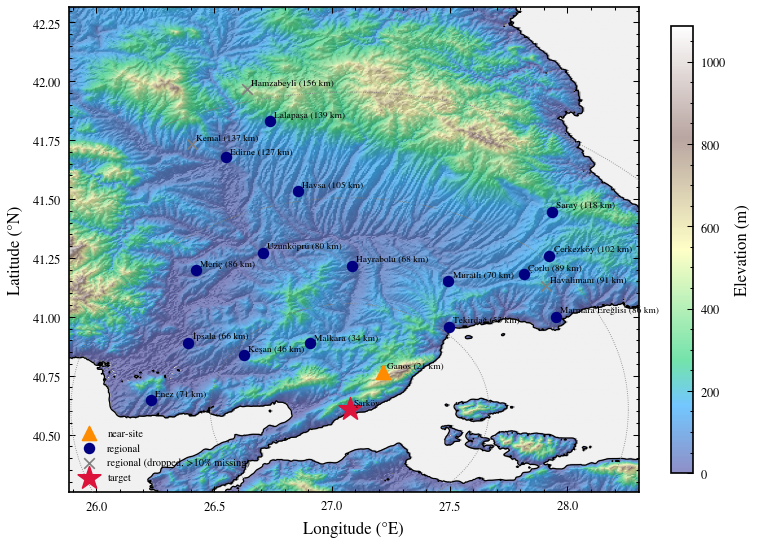

In [5]:
# --- Terrain and the station map (Figure 1) --------------------------------------------------------
import math, io as _io, urllib.request
def _tile(lon, lat, z):
    n = 2 ** z
    x = int((lon + 180.0) / 360.0 * n)
    y = int((1.0 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2.0 * n)
    return x, y
def _lat(y, z):
    n = 2 ** z
    return math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
def fetch_dem(lon0, lon1, lat0, lat1, z=8):
    from PIL import Image
    x0, y1 = _tile(lon0, lat0, z); x1, y0 = _tile(lon1, lat1, z)
    rows = []
    for ty in range(y0, y1 + 1):
        cols = []
        for tx in range(x0, x1 + 1):
            url = f'https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{tx}/{ty}.png'
            with urllib.request.urlopen(url, timeout=30) as r:
                a = np.asarray(Image.open(_io.BytesIO(r.read())).convert('RGB'), dtype=float)
            cols.append((a[:, :, 0] * 256 + a[:, :, 1] + a[:, :, 2] / 256) - 32768)
        rows.append(np.hstack(cols))
    dem = np.vstack(rows)
    n = 2 ** z
    ext = [(x0 / n) * 360 - 180, ((x1 + 1) / n) * 360 - 180, _lat(y1 + 1, z), _lat(y0, z)]
    return dem, ext

pad = 0.35
lon0, lon1 = meta.longitude.min() - pad, meta.longitude.max() + pad
lat0, lat1 = meta.latitude.min() - pad, meta.latitude.max() + pad
fig, ax = plt.subplots(figsize=(5.5, 4.2))
try:
    dem, ext = fetch_dem(lon0, lon1, lat0, lat1, z=8)
    from matplotlib.colors import LightSource, TwoSlopeNorm
    land = np.where(dem > 0, dem, np.nan)
    ls = LightSource(azdeg=315, altdeg=45)
    ax.imshow(ls.hillshade(np.nan_to_num(land), vert_exag=25), extent=ext, cmap='gray', alpha=0.55, origin='upper')
    im = ax.imshow(land, extent=ext, cmap='terrain', alpha=0.55, origin='upper', vmin=0, vmax=np.nanpercentile(land, 99))
    ax.contour(np.linspace(ext[0], ext[1], dem.shape[1]), np.linspace(ext[3], ext[2], dem.shape[0]),
               dem, levels=[0], colors='k', linewidths=0.6)
    fig.colorbar(im, ax=ax, fraction=0.035, label='Elevation (m)')
except Exception as e:
    print('terrain tiles unavailable (', e, ') — drawing without relief')
style = {'target': ('*', 130, 'crimson'), 'near-site': ('^', 45, 'darkorange'),
         'regional': ('o', 22, 'navy'), 'regional (dropped, >10% missing)': ('x', 26, 'grey')}
for role, g in meta.groupby('role'):
    mk, sz, col = style.get(role, ('o', 20, 'k'))
    ax.scatter(g.longitude, g.latitude, marker=mk, s=sz, c=col, label=role, zorder=5, linewidths=0.8)
for r in meta.itertuples():
    ax.annotate(f'{r.station_name}' + ('' if r.station_key == 'sarkoy' else f' ({r.distance_km:.0f} km)'),
                (r.longitude, r.latitude), fontsize=4.5, xytext=(2, 2), textcoords='offset points', zorder=6)
for d in (50, 100, 150):
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(s.longitude + (d / 111.32) * np.cos(th) / np.cos(np.radians(s.latitude)),
            s.latitude + (d / 111.32) * np.sin(th), color='grey', lw=0.4, ls=':', zorder=4)
ax.set_xlim(lon0, lon1); ax.set_ylim(lat0, lat1)
ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
ax.legend(frameon=False, fontsize=5, loc='lower left')
ru.savefig(fig, REV, 'fig1_station_map'); plt.show()


saved figure figS3_design_diagram


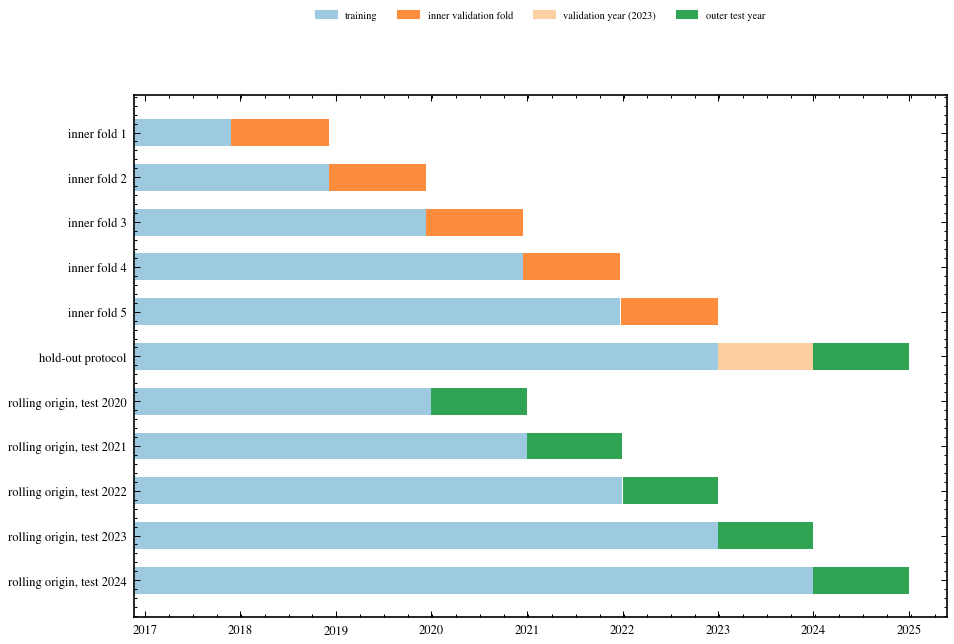

,fold,train_start,train_end,train_days,val_start,val_end,val_days,gap_days
0,1,2016-11-19,2017-11-27,374,2017-11-28,2018-12-04,372,0
1,2,2016-11-19,2018-12-04,746,2018-12-05,2019-12-11,372,0
2,3,2016-11-19,2019-12-11,1118,2019-12-12,2020-12-17,372,0
3,4,2016-11-19,2020-12-17,1490,2020-12-18,2021-12-24,372,0
4,5,2016-11-19,2021-12-24,1862,2021-12-25,2022-12-31,372,0


In [6]:
# --- Chronological design diagram (Figure S3) ------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates
df = ru.load_matrix(BASE, REV, 'causal', verbose=False)
idx = df.index
tr_idx = idx[idx.year <= 2022]
folds = list(TimeSeriesSplit(n_splits=5).split(np.arange(len(tr_idx))))
bars, labels = [], []
for k, (a, b) in enumerate(folds):
    bars.append([(tr_idx[a[0]], tr_idx[a[-1]], '#9ecae1'), (tr_idx[b[0]], tr_idx[b[-1]], '#fd8d3c')])
    labels.append(f'inner fold {k + 1}')
bars.append([(idx.min(), tr_idx[-1], '#9ecae1'), (pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), '#fdd0a2'),
             (pd.Timestamp('2024-01-01'), idx.max(), '#31a354')])
labels.append('hold-out protocol')
years = sorted(int(k) for k in json.load(open(REV + 'rolling_origin_params.json'))) if os.path.exists(REV + 'rolling_origin_params.json') else [2020, 2021, 2022, 2023, 2024]
for Y in years:
    bars.append([(idx.min(), pd.Timestamp(f'{Y - 1}-12-31'), '#9ecae1'),
                 (pd.Timestamp(f'{Y}-01-01'), min(idx.max(), pd.Timestamp(f'{Y}-12-31')), '#31a354')])
    labels.append(f'rolling origin, test {Y}')
fig, ax = plt.subplots(figsize=(7.0, 0.32 * len(bars) + 1.0))
for i, segs in enumerate(bars):
    for a, b, c in segs:
        ax.barh(i, mdates.date2num(b) - mdates.date2num(a), left=mdates.date2num(a), height=0.6, color=c)
ax.set_yticks(range(len(bars))); ax.set_yticklabels(labels, fontsize=6); ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ('#9ecae1', '#fd8d3c', '#fdd0a2', '#31a354')]
ax.legend(handles, ['training', 'inner validation fold', 'validation year (2023)', 'outer test year'],
          frameon=False, fontsize=5, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.18))
ru.savefig(fig, REV, 'figS3_design_diagram'); plt.show()
fold_tbl = pd.DataFrame([dict(fold=k + 1, train_start=tr_idx[a[0]].date(), train_end=tr_idx[a[-1]].date(),
                              train_days=len(a), val_start=tr_idx[b[0]].date(), val_end=tr_idx[b[-1]].date(),
                              val_days=len(b), gap_days=0) for k, (a, b) in enumerate(folds)])
fold_tbl.to_csv(REV + 'tables/S7_inner_fold_borders.csv', index=False)
display(fold_tbl)


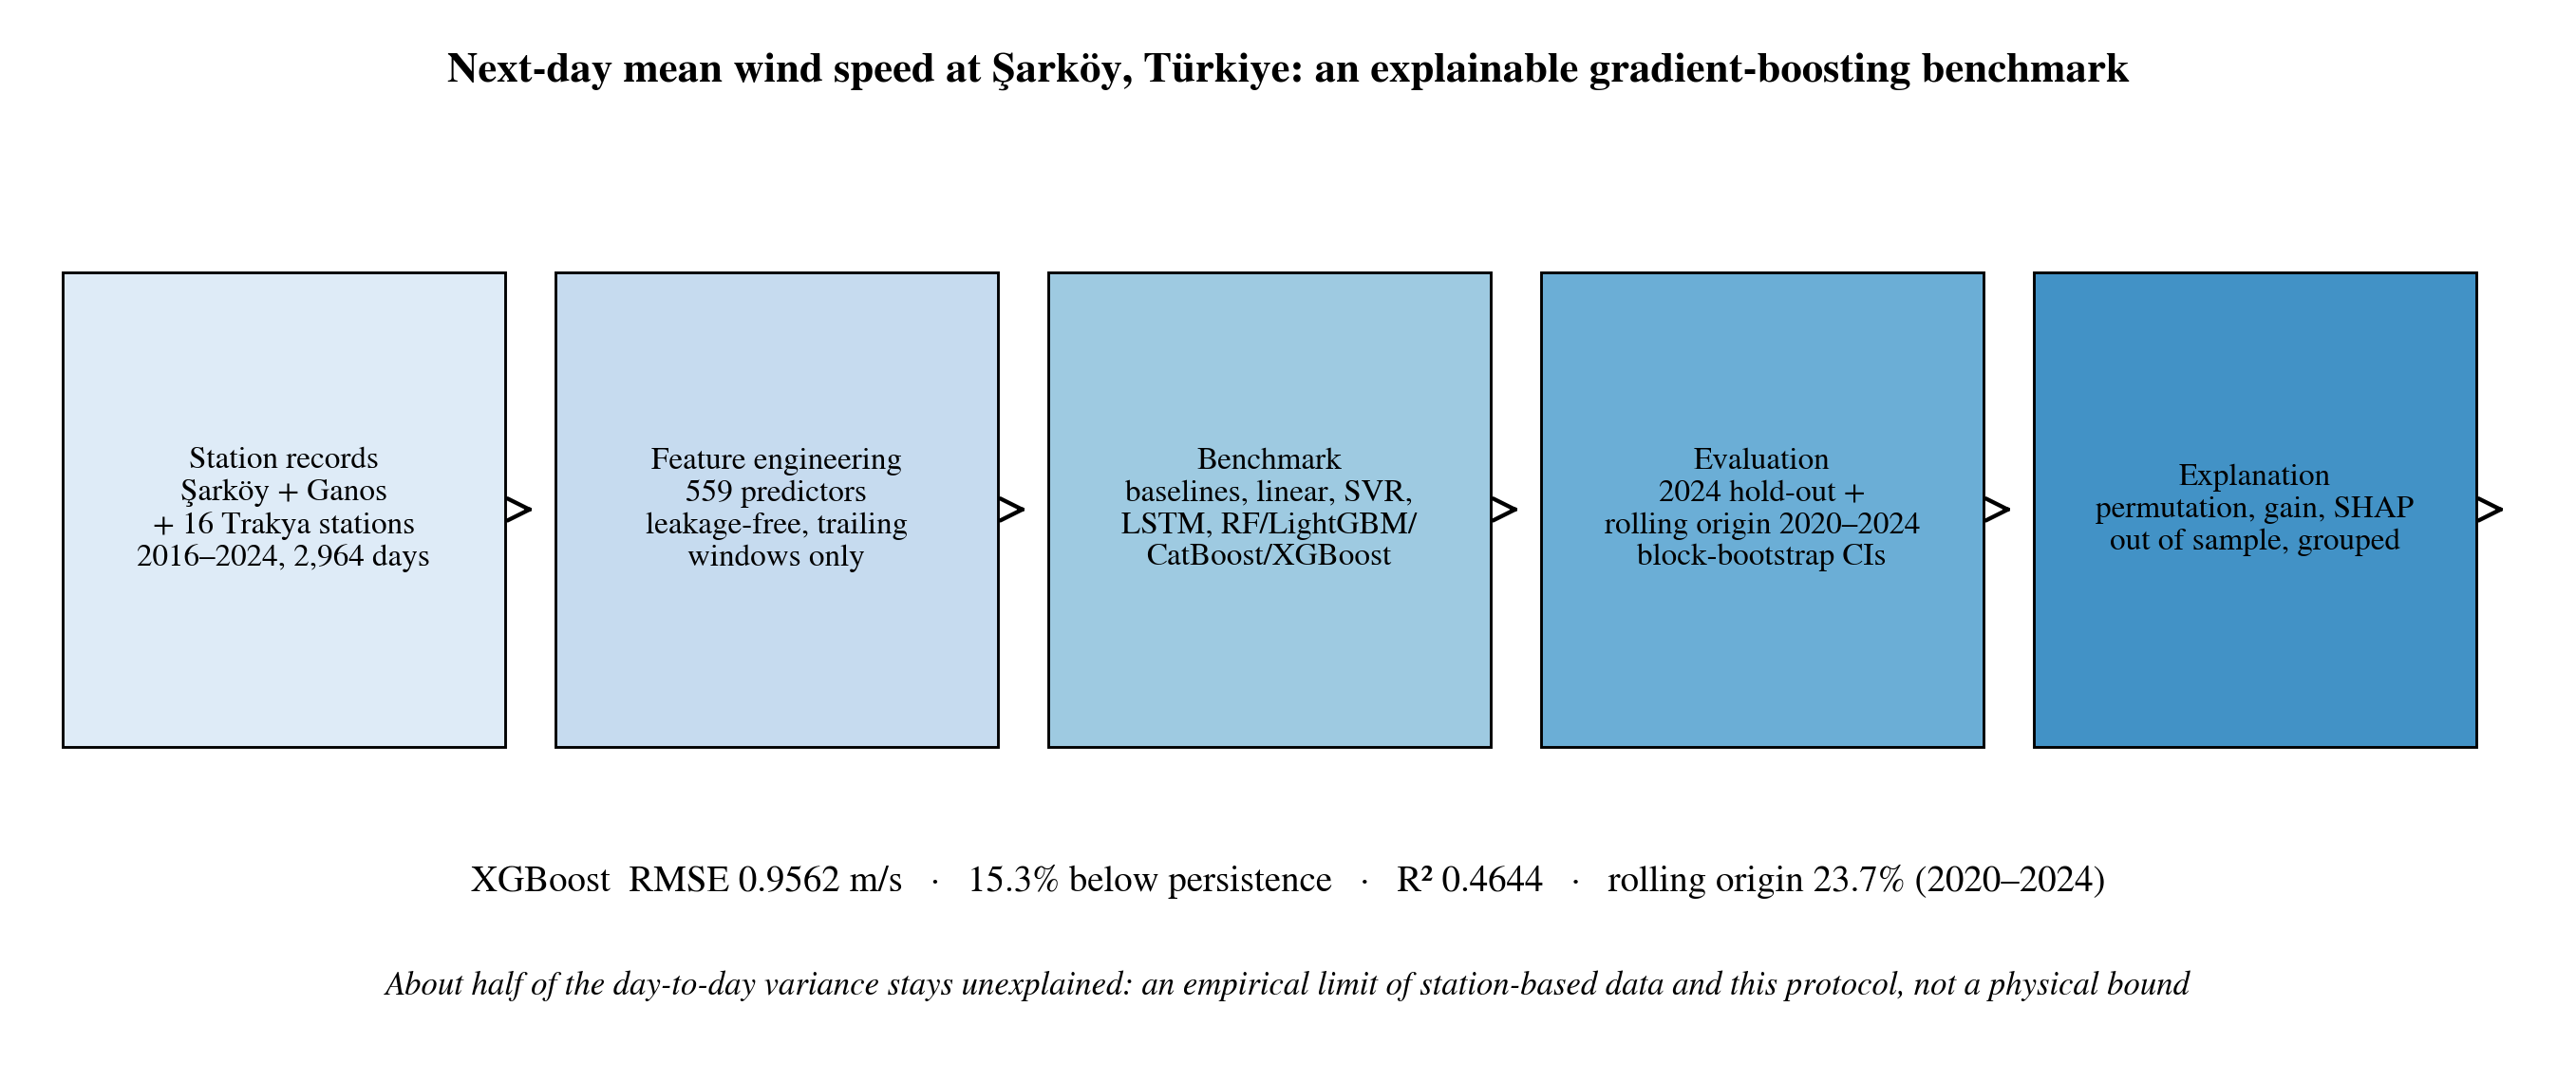

graphical abstract size: [2661.41732283 1087.08661417]
5 values written to /content/drive/MyDrive/windforecast_rev1/revision/results_13.json


In [7]:
# --- Graphical abstract ----------------------------------------------------------------------------
R_ = json.load(open(REV + 'revision_results.json')) if os.path.exists(REV + 'revision_results.json') else {}
def g(k, d):
    return R_.get(k, d)
fig = plt.figure(figsize=(13 / 2.54, 5.31 / 2.54), dpi=520)
ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
boxes = [('Station records\nŞarköy + Ganos\n+ 16 Trakya stations\n2016–2024, 2,964 days', '#deebf7'),
         ('Feature engineering\n559 predictors\nleakage-free, trailing\nwindows only', '#c6dbef'),
         ('Benchmark\nbaselines, linear, SVR,\nLSTM, RF/LightGBM/\nCatBoost/XGBoost', '#9ecae1'),
         ('Evaluation\n2024 hold-out +\nrolling origin 2020–2024\nblock-bootstrap CIs', '#6baed6'),
         ('Explanation\npermutation, gain, SHAP\nout of sample, grouped', '#4292c6')]
x = 0.015
for txt, col in boxes:
    ax.add_patch(plt.Rectangle((x, 0.30), 0.175, 0.46, fc=col, ec='k', lw=0.4))
    ax.text(x + 0.0875, 0.53, txt, ha='center', va='center', fontsize=4.6)
    if x < 0.8:
        ax.annotate('', xy=(x + 0.192, 0.53), xytext=(x + 0.178, 0.53), arrowprops=dict(arrowstyle='->', lw=0.6))
    x += 0.195
ax.text(0.5, 0.945, 'Next-day mean wind speed at Şarköy, Türkiye: an explainable gradient-boosting benchmark',
        ha='center', fontsize=6.2, weight='bold')
ax.text(0.5, 0.16, f"XGBoost  RMSE {g('T1_XGB400_RMSE', '0.958')} m/s   ·   "
                   f"{g('T1_XGB400_SKILL', '15.2')}% below persistence   ·   R² {g('T1_XGB400_R2', '0.463')}"
                   f"   ·   rolling origin {g('RO_POOLED_SKILL', '—')}% (2020–2024)",
        ha='center', fontsize=5.4)
ax.text(0.5, 0.06, 'About half of the day-to-day variance stays unexplained: an empirical limit of station-based '
                   'data and this protocol, not a physical bound', ha='center', fontsize=4.8, style='italic')
for ext in ('png', 'pdf', 'tif'):
    try:
        fig.savefig(REV + 'figures/graphical_abstract.' + ext, dpi=520, bbox_inches=None)
    except Exception as e:
        print('skip', ext, e)
plt.show()
print('graphical abstract size:', fig.get_size_inches() * 520)
RES.save()
